In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [23]:
import warnings # ignore warnings
warnings.filterwarnings('ignore')

In [24]:
# Let's load our dataset
df = pd.read_csv('C:/Users/HP/OneDrive/7CS030/Assessment/nba_rookie_data.csv')

In [25]:
df.head()

,Name,Games Played,Minutes Played,Points Per Game,Field Goals Made,Field Goal Attempts,Field Goal Percent,3 Point Made,3 Point Attempt,3 Point Percent,...,Free Throw Attempts,Free Throw Percent,Offensive Rebounds,Defensive Rebounds,Rebounds,Assists,Steals,Blocks,Turnovers,TARGET_5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [26]:
df.isna().sum()

Name                    0
Games Played            0
Minutes Played          0
Points Per Game         0
Field Goals Made        0
Field Goal Attempts     0
Field Goal Percent      0
3 Point Made            0
3 Point Attempt         0
3 Point Percent        11
Free Throw Made         0
Free Throw Attempts     0
Free Throw Percent      0
Offensive Rebounds      0
Defensive Rebounds      0
Rebounds                0
Assists                 0
Steals                  0
Blocks                  0
Turnovers               0
TARGET_5Yrs             0
dtype: int64

In [27]:
df = df.dropna()

In [28]:
# ### DATA VISUALIZATION AND ANALYSIS

# Let's drop the name column first
df_corr= df.drop(df.columns[0], axis=1) 
df_corr.corr()

,Games Played,Minutes Played,Points Per Game,Field Goals Made,Field Goal Attempts,Field Goal Percent,3 Point Made,3 Point Attempt,3 Point Percent,Free Throw Made,Free Throw Attempts,Free Throw Percent,Offensive Rebounds,Defensive Rebounds,Rebounds,Assists,Steals,Blocks,Turnovers,TARGET_5Yrs
Games Played,1.000000,0.590596,0.539069,0.543000,0.517395,0.296987,0.108195,0.099626,0.038209,0.483185,0.480136,0.197743,0.400184,0.467467,0.460390,0.374311,0.452726,0.276700,0.518693,0.397783
Minutes Played,0.590596,1.000000,0.911746,0.902864,0.910194,0.208341,0.389474,0.402814,0.165997,0.791089,0.779813,0.236160,0.573655,0.747065,0.710853,0.629147,0.757050,0.401011,0.826431,0.316031
Points Per Game,0.539069,0.911746,1.000000,0.990874,0.979676,0.261587,0.345289,0.355198,0.151072,0.896245,0.880826,0.254404,0.576421,0.696560,0.679002,0.551561,0.674937,0.390496,0.850272,0.314632
Field Goals Made,0.543000,0.902864,0.990874,1.000000,0.980117,0.297113,0.287956,0.297898,0.119493,0.848146,0.840667,0.219423,0.597468,0.705191,0.692678,0.532261,0.662457,0.400744,0.834343,0.316393
Field Goal Attempts,0.517395,0.910194,0.979676,0.980117,1.000000,0.135815,0.388860,0.412053,0.197160,0.826244,0.805507,0.264405,0.505547,0.642752,0.616497,0.589038,0.689771,0.325503,0.845952,0.290684
Field Goal Percent,0.296987,0.208341,0.261587,0.297113,0.135815,1.000000,-0.291573,-0.347680,-0.330690,0.253381,0.306360,-0.150996,0.512346,0.411103,0.466126,-0.103546,0.061130,0.390786,0.126429,0.235587
3 Point Made,0.108195,0.389474,0.345289,0.287956,0.388860,-0.291573,1.000000,0.982579,0.589855,0.155717,0.093059,0.312256,-0.218210,0.018688,-0.070865,0.374314,0.305146,-0.155955,0.257015,0.035025
3 Point Attempt,0.099626,0.402814,0.355198,0.297898,0.412053,-0.347680,0.982579,1.000000,0.582337,0.170463,0.105784,0.320901,-0.231050,0.013611,-0.079111,0.408066,0.336757,-0.169245,0.282496,0.016151
3 Point Percent,0.038209,0.165997,0.151072,0.119493,0.197160,-0.330690,0.589855,0.582337,1.000000,0.030320,-0.032333,0.326372,-0.288759,-0.122949,-0.191071,0.262120,0.194329,-0.242274,0.108277,-0.003411
Free Throw Made,0.483185,0.791089,0.896245,0.848146,0.826244,0.253381,0.155717,0.170463,0.030320,1.000000,0.980626,0.253125,0.586325,0.657652,0.657194,0.474403,0.599534,0.412565,0.804762,0.295546


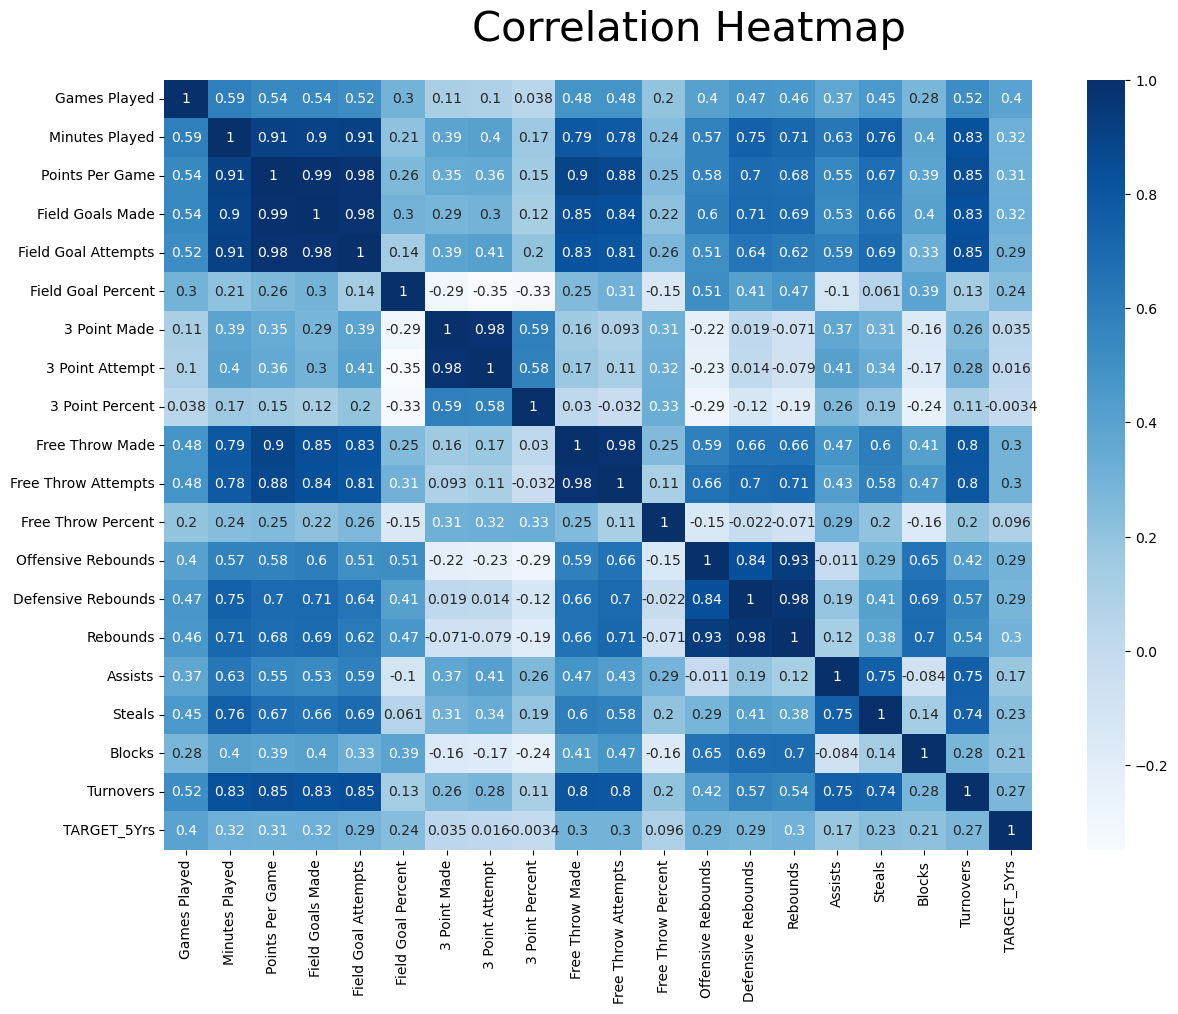

In [79]:
# Next we visualize through the correlation heatmap
corr = df_corr.corr()
fig, ax=plt.subplots(figsize=(14,10))
fig.suptitle('Correlation Heatmap', fontsize=30, y=.95)
fig.savefig('Correlation_Heatmap')
heatmap = sns.heatmap(corr, cmap='Blues', annot=True)

In [30]:
X = df_corr.iloc[:, [0,2]].values  # input are 2 features (Games Played, Points Per Game)
y = df_corr.iloc[:, -1].values 

In [31]:
X

array([[36. ,  7.4],
       [35. ,  7.2],
       [74. ,  5.2],
       ...,
       [43. ,  5.4],
       [52. ,  4.5],
       [47. ,  4.4]])

In [32]:
y

array([0, 0, 0, ..., 0, 1, 1])

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
	test_size= 1/5, random_state=42)

In [40]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
# Train the logistic regression model
Lreg = LogisticRegression()
Lreg.fit(X_train_scaled, y_train)

LogisticRegression()

In [42]:
Lreg = model = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=2000)
Lreg.fit(X_train, y_train)

LogisticRegression(max_iter=2000, multi_class='auto')

In [43]:
# print the accuracy score & number of mislabeled points of the trained data
print('Accuracy is %2.f' % Lreg.score(X_train, y_train))
print('Number of mislabeled points out of a total of %d points: %d' 
      %(X_test.shape[0], (y_test != Lreg.predict(X_test)).sum()))

Accuracy is  1
Number of mislabeled points out of a total of 266 points: 68


In [44]:
# print the accuracy score & number of mislabeled points of test data
print('Accuracy is %.2f' %Lreg.score(X_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X_test.shape[0], (y_test != Lreg.predict(X_test)).sum()))

Accuracy is 0.74
Number of mislabeled points out of a total 266 points: 68


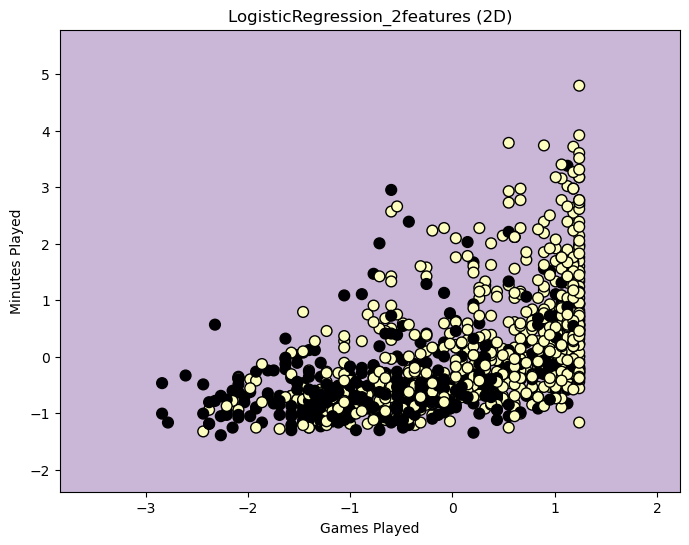

In [49]:
# Let's viaualize using Logistic Regression Plot
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = Lreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Define feature names 
feature1 = "Games Played" 
feature2 = "Minutes Played"  

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap='magma', alpha=0.3)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='magma', edgecolor='k', s=60)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('LogisticRegression_2features (2D)')
plt.savefig('LogisticR.png')
plt.show()

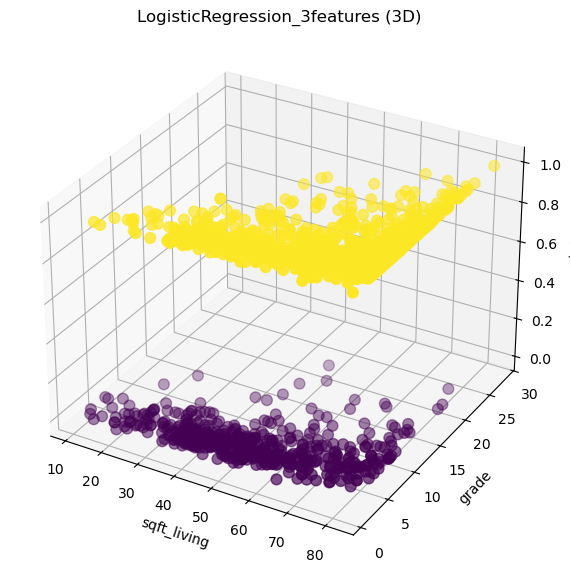

In [52]:
# 3D Visualization
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], y, c=y, cmap='viridis', s=60)
ax.set_xlabel('sqft_living')
ax.set_ylabel('grade')
ax.set_zlabel('price')

plt.title("3D Visualization of Two Features vs Target", fontsize=12)
plt.title('LogisticRegression_3features (3D)')
plt.savefig('3D_LogisticR.png')
plt.show()

In [53]:
# Let's test another model and call it Gaussian Naive Bayes

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
	test_size= 1/5, random_state=42)

In [56]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

GaussianNB()

In [57]:
# let's print the accuracy score & number of mislabeled points of test data
print('Our Accuracy is %.2f' % gnb.score(X_test, y_test))
print('Number of mislabeled points out of a total %d points : %d'
		% (X_test.shape[0], (y_test != gnb.predict(X_test)).sum()))

Our Accuracy is 0.33
Number of mislabeled points out of a total 266 points : 178


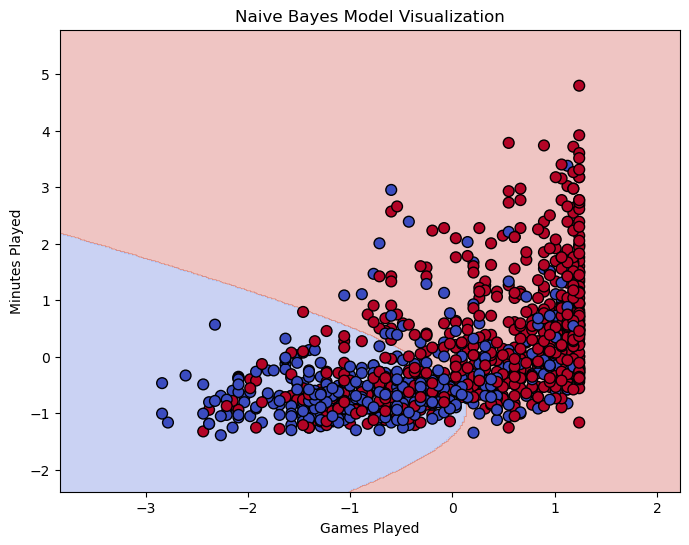

In [58]:
# Gaussian Naive Bayes Visualization
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='coolwarm', edgecolor='k', s=60)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Naive Bayes Model Visualization')
plt.savefig('Naive_Bayes_Decision.png')
plt.show()

Text(0, 0.5, 'Points Per Game')

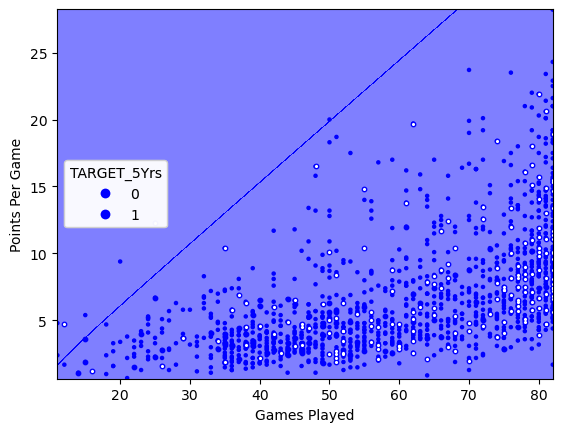

In [60]:
# An alternative Visualization

fig, ax = plt.subplots()

# setting up color and symbol encoding
nm = Normalize(vmin = 1, vmax = 3)
cm = ListedColormap(['blue', 'red', 'green'])
m = ['o', 's', 'D']

scatter1 = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cm, 
    norm = nm, s = 5)

# we have to set up a mesh for the contour of the model
x_min, x_max = X[:, 0].min() - 0.05, X[:, 0].max() + 0.05
y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05

h = 0.01  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), 
	np.arange(y_min, y_max, h))

# the model predicts every point in the mesh and reshapes the array for plotting
Z = gnb.predict(np.column_stack([xx.ravel(), 
	yy.ravel()]))
Z = Z.reshape(xx.shape)

# contour plot
ax.contourf(xx, yy, Z, cmap = cm, norm = nm, alpha=0.5)


# plot the data
for i in range(len(X_test)):
	ax.scatter(X_test[i,0], X_test[i,1], 
		marker = 'o', 
		c = y_test[i], cmap = cm, norm = nm, s = 10)


# identify misclassified points
mis_ind = np.where(y_test != gnb.predict(X_test))[0]


# plot the misclassified points
ax.scatter(X_test[mis_ind,0], X_test[mis_ind,1], 
		marker = '*', color = 'white', s = 2)


legend1 = ax.legend(*scatter1.legend_elements(),
                    loc="center left", title="TARGET_5Yrs")


ax.add_artist(legend1)


ax.set_xlabel('Games Played')
ax.set_ylabel('Points Per Game')


In [61]:
#X = df_corr.iloc[:, [0,1,2,3]].values  # input are 4 features (Games Played, Minutes Played, Points Per Game, Field Goals Made)
X1 = df_corr.iloc[:, [0,1,2,3]].values
y = df_corr.iloc[:, -1].values

In [62]:
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, 
	test_size= 1/5, random_state=42)

In [63]:
MLreg = model = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=2000)
MLreg.fit(X1_train, y_train)

LogisticRegression(max_iter=2000, multi_class='auto')

In [64]:
# print the accuracy score & number of mislabeled points of test data
print('Our Accuracy is %.2f' % MLreg.score(X1_test, y_test))
print('Number of mislabeled points out of a total %d points : %d'
		% (X1_test.shape[0], (y_test != MLreg.predict(X1_test)).sum()))

Our Accuracy is 0.74
Number of mislabeled points out of a total 266 points : 69


In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
	test_size= 1/5, random_state=42)

In [68]:
# Applying the GNB model on 4 features
Four_gnb = GaussianNB()
Four_gnb.fit(X_train, y_train)  # X_train 4 features

GaussianNB()

In [69]:
# print the accuracy score & number of mislabeled points of test data
print('Our Accuracy is %.2f' % Four_gnb.score(X_test, y_test))
print('Number of mislabeled points out of a total %d points : %d'
		% (X_test.shape[0], (y_test != Four_gnb.predict(X_test)).sum()))

Our Accuracy is 0.71
Number of mislabeled points out of a total 266 points : 77


In [70]:
# Testing with all features except target
#X = df_corr.iloc[:, :-1].values  
X = df_corr.iloc[:, :-1].values 
y = df_corr.iloc[:, -1].values 

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
	test_size= 1/5, random_state=42)

In [72]:
All_Lreg = model = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=2000)
All_Lreg.fit(X_train, y_train)

LogisticRegression(max_iter=2000, multi_class='auto')

In [74]:
# print the accuracy score & number of mislabeled points of test data
print('Our Accuracy is %.2f' % All_Lreg.score(X_test, y_test))
print('Number of mislabeled points out of a total %d points : %d'
		% (X_test.shape[0], (y_test != All_Lreg.predict(X_test)).sum()))

Our Accuracy is 0.74
Number of mislabeled points out of a total 266 points : 70


In [76]:
# Apply GNB
All_gnb = GaussianNB()

In [77]:
All_gnb.fit(X1_train, y_train)

GaussianNB()

In [78]:
# print the accuracy score & number of mislabeled points of test data
print('Our Accuracy is %.2f' % All_gnb.score(X1_test, y_test))
print('Number of mislabeled points out of a total %d points : %d'
		% (X_test.shape[0], (y_test != All_gnb.predict(X1_test)).sum()))

Our Accuracy is 0.65
Number of mislabeled points out of a total 266 points : 93
